                                                 text  cluster
0   Tuscan kitchen Interior National examples desc...        2
1   Giant foyer Architecture Suburban houses 2000-...        0
2   Wrought-iron staircase Architecture Suburban h...        0
3   Decorative grapes Decor Kitchen and home decor...        1
4   Rooster decor Decor Kitchen 2000-2008 Plates, ...        1
5   Beige walls Interior Suburban houses 2000-2008...        0
6   Dark cherry cabinets Interior Kitchen 2000-200...        4
7   Granite countertops Interior Kitchen 2000-2008...        4
8   Travertine tile Interior Kitchen and floors 20...        4
9   Heavy iron fixtures Interior Suburban houses 2...        0
10  Fake stone Exterior/interior Suburban houses 2...        3
11  Textured stucco Exterior Suburban houses 2000-...        3
12  Arches Architecture Suburban houses 2000-2008 ...        0
13  Columns Architecture Suburban houses 2000-2008...        0
14  Decorative beams Interior Suburban houses 2000...  

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4687/2930119125.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


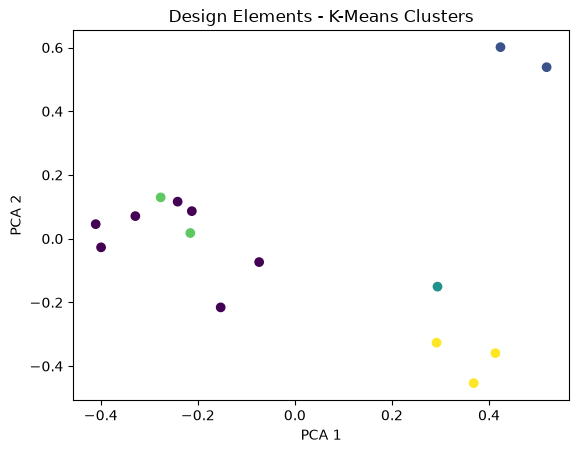

In [1]:
# NLP + K-Means on Design Elements Dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv("design-elements-directory.csv")

# 2. Combine all text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

# 3. Convert text to TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["text"])

# 4. K-Means clustering
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 5. Show clusters
print(df[["text", "cluster"]].head(20))

# 6. Show important words in each cluster
terms = tfidf.get_feature_names_out()

for i, center in enumerate(model.cluster_centers_):
    words = terms[center.argsort()[-10:][::-1]]
    print(f"Cluster {i}: {', '.join(words)}")

# 7. Visualise clusters
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X.toarray())

plt.scatter(X_2D[:, 0], X_2D[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Design Elements - K-Means Clusters")
plt.show()

# 8. Save results
df.to_csv("design-elements-clustered.csv", index=False)